<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/correlation_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [3]:
import os

# See what folders/files exist in the repo root
print(os.listdir('/workspaces/2026-gig-data-analysis'))
print(os.listdir('/workspaces/2026-gig-data-analysis/data'))
print(os.listdir('/workspaces/2026-gig-data-analysis/data/yfinance'))

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/2026-gig-data-analysis'

In [15]:
import pandas as pd

# stock price
#gig_stock_df_annually = pd.read_csv('../../data/yfinance/gig_yfinance_annually.csv', parse_dates=['Date'])
#gig_stock_df_quarterly = pd.read_csv('../../data/yfinance/gig_yfinance_quarterly.csv', parse_dates=['Date'])
gig_stock_df_monthly = pd.read_csv('../../data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])
#sp500_stock_df_annually = pd.read_csv('../../data/yfinance/sp500_yfinance_annually.csv', parse_dates=['Date'])
#sp500_stock_df_quarterly = pd.read_csv('../../data/yfinance/sp500_yfinance_quarterly.csv', parse_dates=['Date'])
sp500_stock_df_monthly = pd.read_csv('../../data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data
#stock_df_annually = pd.concat([gig_stock_df_annually, sp500_stock_df_annually])
#stock_df_quarterly = pd.concat([gig_stock_df_quarterly, sp500_stock_df_quarterly])
stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data
#google_df_annually = pd.read_csv('../../data/google_trends/google_trends_annual.csv', parse_dates=['date'])
#google_df_quarterly = pd.read_csv('../../data/google_trends/google_trends_quarterly.csv', parse_dates=['date'])
google_df_monthly = pd.read_csv('../../data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data
#fred_df_annually = pd.read_csv('../../data/fred/fred_annual_data.csv', parse_dates=['date'])
#fred_df_quarterly = pd.read_csv('../../data/fred/fred_quarterly_data.csv', parse_dates=['date'])
fred_df_monthly = pd.read_csv('../../data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()



,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [16]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left')
)

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.56,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.54,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.70,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.98,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,2.30,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.62,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.78,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.80,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.52,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8


In [19]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].pct_change()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()

/tmp/ipykernel_8070/1141685581.py:9: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Search_change'] = df.groupby('company')['SearchInterest'].pct_change()
/tmp/ipykernel_8070/1141685581.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,Return,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.30,0.0,...,15844.727,3356.4,2.28,95.5,NaN,NaN,NaN,NaN,NaN,NaN
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.32,0.0,...,15844.727,3346.6,2.50,94.1,0.000017,NaN,0.004175,0.1,0.22,-1.4
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.36,0.0,...,15844.727,3339.4,2.63,92.6,0.020848,NaN,0.003638,-0.2,0.13,-1.5
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.26,0.0,...,15922.782,3336.0,2.79,87.7,-0.107597,NaN,0.003107,0.0,0.16,-4.9
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.34,0.0,...,15922.782,3346.6,3.00,86.9,0.007851,NaN,-0.000516,-0.1,0.21,-0.8


In [24]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Herbalife','Primerica','Tupperware','Avon','Etsy','Shopify','Udemy',
                 'Nu skin', 'USANA']

df['CompanyType'] = df['company'].apply(
    lambda x: 'Gig/MLM' if x in gig_companies else 'S&P500'
)

df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,Return,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.30,0.0,...,3356.4,2.28,95.5,NaN,NaN,NaN,NaN,NaN,NaN,S&P500
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.32,0.0,...,3346.6,2.50,94.1,0.000017,NaN,0.004175,0.1,0.22,-1.4,S&P500
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.36,0.0,...,3339.4,2.63,92.6,0.020848,NaN,0.003638,-0.2,0.13,-1.5,S&P500
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.26,0.0,...,3336.0,2.79,87.7,-0.107597,NaN,0.003107,0.0,0.16,-4.9,S&P500
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.34,0.0,...,3346.6,3.00,86.9,0.007851,NaN,-0.000516,-0.1,0.21,-0.8,S&P500


In [27]:
# Define economic stress periods

df['EconomicStress'] = (
    (df['unemployment_data_monthly'] > df['unemployment_data_monthly'].mean()) |
    (df['cpi_data_monthly'] > df['cpi_data_monthly'].mean()) |
    (df['consumer_sentiment_data_monthly'] < df['consumer_sentiment_data_monthly'].mean())
)

df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,Return,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.30,0.0,...,2.28,95.5,NaN,NaN,NaN,NaN,NaN,NaN,S&P500,False
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.32,0.0,...,2.50,94.1,0.000017,NaN,0.004175,0.1,0.22,-1.4,S&P500,False
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.36,0.0,...,2.63,92.6,0.020848,NaN,0.003638,-0.2,0.13,-1.5,S&P500,False
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.26,0.0,...,2.79,87.7,-0.107597,NaN,0.003107,0.0,0.16,-4.9,S&P500,False
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.34,0.0,...,3.00,86.9,0.007851,NaN,-0.000516,-0.1,0.21,-0.8,S&P500,False


# Correlation Matrix

In [30]:
df.groupby(['EconomicStress','CompanyType'])['Close'].mean()

EconomicStress  CompanyType
False           Gig/MLM        28.579709
                S&P500         51.532018
True            Gig/MLM        57.822965
                S&P500         97.872752
Name: Close, dtype: float64

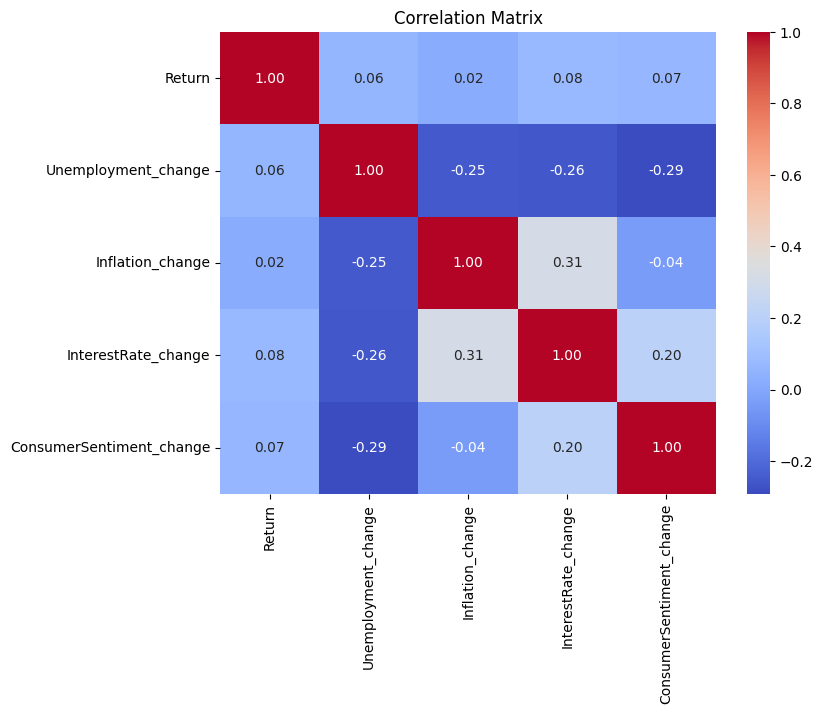

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Select the relevant columns
# -------------------------------
# Adjust column names to match your dataset
cols_to_corr = [
    'Return',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change',
]

corr_df = df[cols_to_corr].dropna()  # remove rows with missing values

# -------------------------------
# Compute correlation matrix
# -------------------------------
corr_matrix = corr_df.corr()

# -------------------------------
# Plot heatmap
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [33]:
gig_df = df[df['CompanyType'] == 'Gig/MLM']
sp500_df = df[df['CompanyType'] == 'S&P500']

gig_df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,Return,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress
36875,2020,12,DoorDash,142.750000,45.0,1.233584,6.7,262.045,0.14,0.0,...,0.09,80.7,NaN,NaN,-0.196257,2.3,-3.63,27.8,Gig/MLM,True
36876,2021,1,DoorDash,193.270004,46.0,4.697859,6.4,262.687,0.16,0.0,...,0.09,79.0,0.353905,0.022222,0.002450,-0.3,0.00,-1.7,Gig/MLM,True
36877,2021,2,DoorDash,169.490005,44.0,4.697859,6.2,263.579,0.14,0.0,...,0.08,76.8,-0.123040,-0.043478,0.003396,-0.2,-0.01,-2.2,Gig/MLM,True
36878,2021,3,DoorDash,131.130005,43.0,4.697859,6.1,264.961,0.12,0.0,...,0.07,84.9,-0.226326,-0.022727,0.005243,-0.1,-0.01,8.1,Gig/MLM,True
36879,2021,4,DoorDash,143.169998,45.0,4.697859,6.1,266.614,0.42,0.0,...,0.07,88.3,0.091817,0.046512,0.006239,0.0,0.00,3.4,Gig/MLM,True


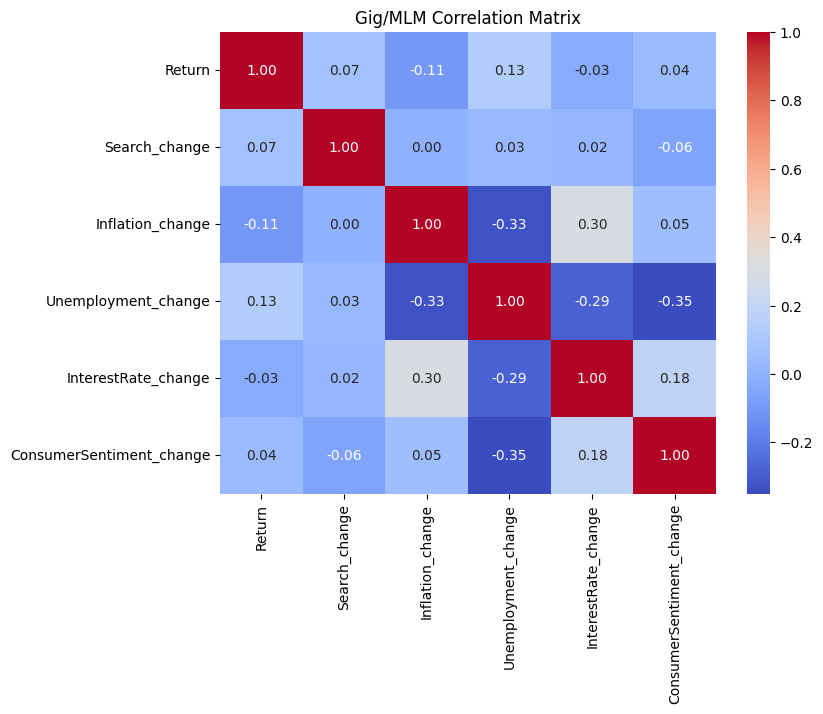

In [36]:
cols_to_corr = [
    'Return',
    'Search_change',
    'Inflation_change',
    'Unemployment_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

corr_df = gig_df[cols_to_corr].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Gig/MLM Correlation Matrix")
plt.show()

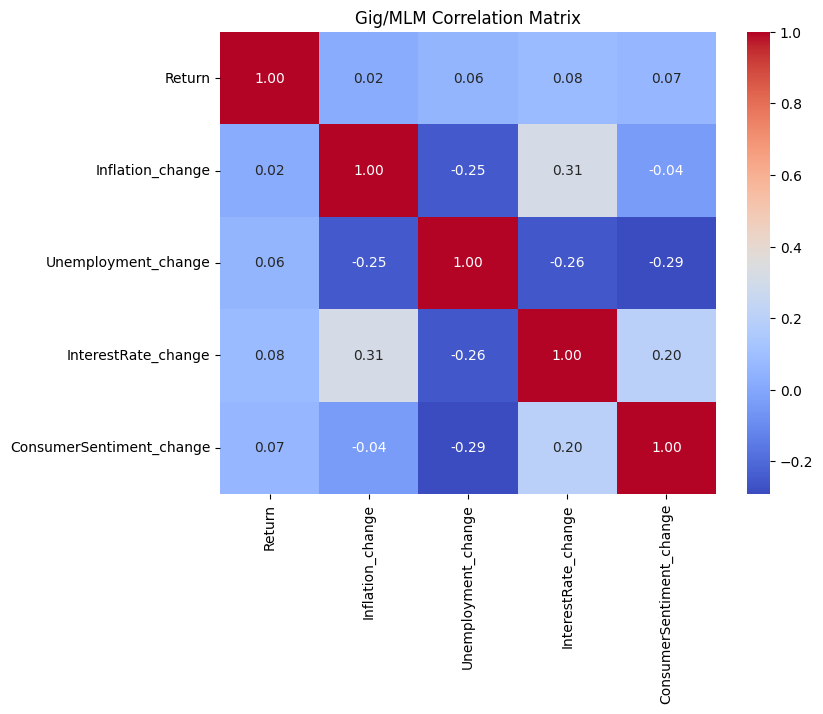

In [38]:
cols_to_corr = [
    'Return',
    'Inflation_change',
    'Unemployment_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

corr_df = sp500_df[cols_to_corr].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Gig/MLM Correlation Matrix")
plt.show()

# Economic Stress Analysis

<Axes: xlabel='EconomicStress', ylabel='Return'>

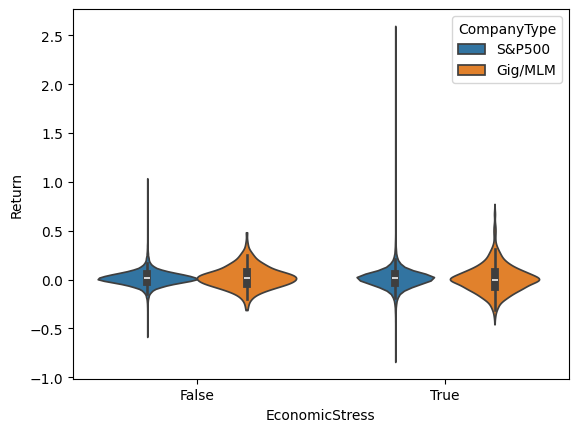

In [50]:
#sns.boxplot(x='EconomicStress', y='Return', data=gig_df)
#sns.boxplot(x='EconomicStress', y='Return', data=sp500_df)
sns.violinplot(x='EconomicStress', y='Return', hue='CompanyType', data=df, cut=0)
#plt.ylim(-0.3, 0.3)

In [51]:
from scipy.stats import ttest_ind

stress_returns = df[df['EconomicStress'] == True]['Return']
nonstress_returns = df[df['EconomicStress'] == False]['Return']

ttest_ind(stress_returns.dropna(), nonstress_returns.dropna())

TtestResult(statistic=np.float64(-4.033091165756772), pvalue=np.float64(5.508307835093204e-05), df=np.float64(116035.0))

In [54]:
# Gig companies
gig_stress = df[(df['CompanyType']=='Gig/MLM') & (df['EconomicStress']==True)]['Return']
gig_nonstress = df[(df['CompanyType']=='Gig/MLM') & (df['EconomicStress']==False)]['Return']

ttest_ind(gig_stress.dropna(), gig_nonstress.dropna())


TtestResult(statistic=np.float64(-1.3328519153582459), pvalue=np.float64(0.18278499694398603), df=np.float64(1484.0))

In [55]:
# S&P500
sp_stress = df[(df['CompanyType']=='S&P500') & (df['EconomicStress']==True)]['Return']
sp_nonstress = df[(df['CompanyType']=='S&P500') & (df['EconomicStress']==False)]['Return']

ttest_ind(sp_stress.dropna(), sp_nonstress.dropna())

TtestResult(statistic=np.float64(-3.9003833553017824), pvalue=np.float64(9.60952535141767e-05), df=np.float64(114549.0))

# CCF: Lag Analysis - Search Interest & Stock Price

In [2]:
# monthly
companies = df['company'].unique()

for c in companies:
    df = df[df['company'] == c].copy()

    # create time index
    df['time'] = df['year'].astype(str) + '-' + df['month'].astype(str)
    df = df.sort_values(['year', 'month'])
    df = df.set_index('time')

    if df['SearchInterest'].notna().sum() > 10:
        x = df['SearchInterest'].fillna(0)
        y = df['Close'].ffill()

        ccf_vals = ccf(x, y)

        plt.plot(ccf_vals)
        plt.title(f'Monthly CCF Search vs Close: {c}')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.show()

NameError: name 'df' is not defined